# CosMx Human Multiomic Breast — assemble AnnData

Builds a single `.h5ad` file from the Bruker CosMx multiomic breast flat files (RNA + Protein, same slide).
Output is structured for KaroSpace:
- `X` / `layers['counts']` — RNA counts (cells × genes)
- `obs.x`, `obs.y`, `obsm['spatial']` — global µm coords
- `obsm['protein']` + `uns['protein_var']` — 64-plex protein per-cell intensities
- `obs.sample`, `obs.fov`, `obs.cell` — identifiers

In [28]:
import gzip, io, json, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad

ROOT  = Path('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast')
OUT_H5AD = ROOT/'cosmx_multiomic_breast.h5ad'
RNA_ZIP  = ROOT/'Flatfiles_RNA.zip'
PRO_ZIP  = ROOT/'Flatfiles_Protein.zip'
EX_DIR   = ROOT/'extracted'
EX_DIR.mkdir(exist_ok=True)
PX_TO_UM = 0.120  # CosMx: ~120 nm/px (verified from fov_positions: px ↔ mm ratio)
SAMPLE_NAME = 'BreastCancer_multiomic'

In [2]:
# Extract zips if not already done
def ensure_extracted(zip_path, marker_glob):
    target = EX_DIR/zip_path.stem
    if list(target.rglob(marker_glob)):
        print('already extracted:', target)
        return target
    print('unzipping', zip_path, '→', target)
    target.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(target)
    return target

rna_root = ensure_extracted(RNA_ZIP, '*exprMat_file.csv.gz')
pro_root = ensure_extracted(PRO_ZIP, '*exprMat_file.csv.gz')

def find_one(root, suffix):
    hits = list(root.rglob(f'*{suffix}'))
    assert len(hits)==1, f'expected exactly 1 match for {suffix} under {root}, got {hits}'
    return hits[0]

rna_files = {k: find_one(rna_root, v) for k,v in {
    'expr':      'exprMat_file.csv.gz',
    'meta':      'metadata_file.csv.gz',
    'fov':       'fov_positions_file.csv.gz',
    'polygons':  'polygons.csv.gz',
}.items()}
pro_files = {k: find_one(pro_root, v) for k,v in {
    'expr':      'exprMat_file.csv.gz',
    'meta':      'metadata_file.csv.gz',
    'fov':       'fov_positions_file.csv.gz',
    'polygons':  'polygons.csv.gz',
}.items()}
print('RNA files:', rna_files)
print('Protein files:', pro_files)

already extracted: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast/extracted/Flatfiles_RNA
already extracted: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast/extracted/Flatfiles_Protein
RNA files: {'expr': PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast/extracted/Flatfiles_RNA/Flatfiles_RNA/flatFiles/BreastCancer/BreastCancer_exprMat_file.csv.gz'), 'meta': PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast/extracted/Flatfiles_RNA/Flatfiles_RNA/flatFiles/BreastCancer/BreastCancer_metadata_file.csv.gz'), 'fov': PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast/extracted/Flatfiles_RNA/Flatfiles_RNA/flatFiles/BreastCan

In [3]:
# --- Load RNA expression matrix (cells × genes) ---
# Header: fov, cell_ID, gene1, gene2, ..., NegPrb*, SystemControl*
print('reading RNA exprMat (large) ...')
rna_expr = pd.read_csv(rna_files['expr'])
print(rna_expr.shape, 'columns[:6]=', list(rna_expr.columns[:6]))
rna_expr['cell_uid'] = rna_expr['fov'].astype(str) + '_' + rna_expr['cell_ID'].astype(str)
feat_cols = [c for c in rna_expr.columns if c not in ('fov','cell_ID','cell_uid')]
is_neg = np.array([c.lower().startswith(('negprb','negprobe','neg_prb','negative')) for c in feat_cols])
is_sys = np.array([c.lower().startswith(('systemcontrol','sys_control','falsecode')) for c in feat_cols])
is_real = ~(is_neg | is_sys)
real_genes = [g for g,r in zip(feat_cols, is_real) if r]
neg_genes  = [g for g,r in zip(feat_cols, is_neg)  if r]
sys_genes  = [g for g,r in zip(feat_cols, is_sys)  if r]
print(f'real genes: {len(real_genes)} | neg probes: {len(neg_genes)} | sys controls: {len(sys_genes)}')

reading RNA exprMat (large) ...
(152451, 20387) columns[:6]= ['fov', 'cell_ID', 'A1BG', 'A1CF', 'A2M', 'A2ML1']
real genes: 18942 | neg probes: 50 | sys controls: 1393


In [4]:
# Build sparse RNA count matrix (cells × genes) and per-cell QC for neg/sys
X_rna = sp.csr_matrix(rna_expr[real_genes].to_numpy(dtype=np.int32))
neg_total = rna_expr[neg_genes].sum(axis=1).to_numpy() if neg_genes else np.zeros(len(rna_expr))
sys_total = rna_expr[sys_genes].sum(axis=1).to_numpy() if sys_genes else np.zeros(len(rna_expr))
rna_obs = pd.DataFrame({
    'fov':      rna_expr['fov'].astype(int).values,
    'cell_ID':  rna_expr['cell_ID'].astype(int).values,
    'cell_uid': rna_expr['cell_uid'].values,
    'nCount_neg': neg_total,
    'nCount_sys': sys_total,
})
print('RNA matrix:', X_rna.shape, 'nnz=', X_rna.nnz)
del rna_expr

RNA matrix: (152451, 18942) nnz= 202163677


In [5]:
# --- Cell metadata (RNA flat files) ---
rna_meta = pd.read_csv(rna_files['meta'])
rna_meta['cell_uid'] = rna_meta['fov'].astype(str) + '_' + rna_meta['cell_ID'].astype(str)
print('rna_meta', rna_meta.shape, 'cols sample:', list(rna_meta.columns[:20]))
# Keep only the columns useful for KaroSpace + QC
keep_meta_cols = [c for c in [
    'cell_uid','fov','cell_ID','cell','CenterX_local_px','CenterY_local_px',
    'CenterX_global_px','CenterY_global_px','Area','Area.um2','AspectRatio',
    'Width','Height','Circularity','Eccentricity','Solidity','Perimeter',
    'Mean.DAPI','Max.DAPI','Mean.PanCK','Max.PanCK','Mean.CD45','Max.CD45',
    'Mean.CD68','Max.CD68','Mean.Membrane','Max.Membrane',
    'nCount_RNA','nFeature_RNA','nCount_negprobes','nFeature_negprobes',
    'slide_ID','tissue','Panel','assay_type','Run_Tissue_name','Run_name'
] if c in rna_meta.columns]
rna_meta = rna_meta[keep_meta_cols].copy()
rna_obs = rna_obs.merge(rna_meta, on=['cell_uid','fov','cell_ID'], how='left')
print('rna_obs:', rna_obs.shape)

rna_meta (152451, 69) cols sample: ['fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio']
rna_obs: (152451, 39)


In [6]:
# --- Protein expression matrix (cells × proteins, mean intensities) ---
pro_expr = pd.read_csv(pro_files['expr'])
pro_expr['cell_uid'] = pro_expr['fov'].astype(str) + '_' + pro_expr['cell_ID'].astype(str)
pro_feat_cols = [c for c in pro_expr.columns if c not in ('fov','cell_ID','cell_uid')]
iso_mask = np.array([c.startswith(('Ms IgG','Rb IgG')) for c in pro_feat_cols])
channel_mask = np.array([c.startswith('Channel-') for c in pro_feat_cols])
real_pro = [p for p,iso,ch in zip(pro_feat_cols, iso_mask, channel_mask) if not (iso or ch)]
iso_pro  = [p for p,iso in zip(pro_feat_cols, iso_mask) if iso]
ch_pro   = [p for p,ch  in zip(pro_feat_cols, channel_mask) if ch]
print(f'protein features: real={len(real_pro)} isotypes={len(iso_pro)} channels={len(ch_pro)}')

protein features: real=62 isotypes=2 channels=5


In [7]:
# --- Align cells between RNA and Protein by (fov, cell_ID) ---
rna_idx = pd.Index(rna_obs['cell_uid'])
pro_idx = pd.Index(pro_expr['cell_uid'])
shared  = rna_idx.intersection(pro_idx)
print(f'cells: RNA={len(rna_idx)}  Protein={len(pro_idx)}  shared={len(shared)}')

# Subset and reorder both to shared cells, RNA order = canonical
keep = rna_obs['cell_uid'].isin(shared).values
X_rna  = X_rna[keep]
rna_obs = rna_obs.loc[keep].reset_index(drop=True)
pro_expr = pro_expr.set_index('cell_uid').loc[rna_obs['cell_uid'].values].reset_index()
assert (pro_expr['cell_uid'].values == rna_obs['cell_uid'].values).all()
print('aligned cells:', X_rna.shape[0])

P_real = pro_expr[real_pro].to_numpy(dtype=np.float32)
P_iso  = pro_expr[iso_pro].to_numpy(dtype=np.float32) if iso_pro else None
P_ch   = pro_expr[ch_pro].to_numpy(dtype=np.float32)  if ch_pro  else None
print('protein matrix:', P_real.shape)

cells: RNA=152451  Protein=153839  shared=152451
aligned cells: 152451
protein matrix: (152451, 62)


In [8]:
# --- Spatial coords (µm) from RNA metadata ---
rna_obs['x'] = rna_obs['CenterX_global_px'].astype(float) * PX_TO_UM
rna_obs['y'] = rna_obs['CenterY_global_px'].astype(float) * PX_TO_UM
rna_obs['sample'] = SAMPLE_NAME
rna_obs.index = rna_obs['cell_uid'].astype(str)
rna_obs.index.name = 'obs'
rna_obs.head(3)

,fov,cell_ID,cell_uid,nCount_neg,nCount_sys,cell,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,...,nFeature_negprobes,slide_ID,tissue,Panel,assay_type,Run_Tissue_name,Run_name,x,y,sample
obs,,,,,,,,,,,,,,,,,,,,,
33_1,33,1,33_1,0,1,c_1_33_1,2053,178,15078,123390.0,...,0,1,Breast Cancer,WTX,RNA,Breast Cancer,MOM_10_Breast,1809.36,14806.80,BreastCancer_multiomic
33_2,33,2,33_2,0,3,c_1_33_2,4180,631,17205,122937.0,...,0,1,Breast Cancer,WTX,RNA,Breast Cancer,MOM_10_Breast,2064.60,14752.44,BreastCancer_multiomic
33_3,33,3,33_3,0,0,c_1_33_3,4006,727,17031,122841.0,...,0,1,Breast Cancer,WTX,RNA,Breast Cancer,MOM_10_Breast,2043.72,14740.92,BreastCancer_multiomic


In [9]:
# --- Build AnnData ---
var_df = pd.DataFrame(index=pd.Index(real_genes, name='gene'))
var_df['feature_type'] = 'gene'

adata = ad.AnnData(
    X=X_rna,
    obs=rna_obs.drop(columns=['cell_uid']),
    var=var_df,
    layers={'counts': X_rna},
    obsm={'spatial': rna_obs[['x','y']].to_numpy(dtype=np.float32)},
)

# Protein modality: store as obsm + var-level metadata in uns
adata.obsm['protein'] = P_real
adata.uns['protein_var'] = pd.DataFrame({'protein': real_pro, 'feature_type': 'protein'})
if P_iso is not None:
    adata.obsm['protein_isotype'] = P_iso
    adata.uns['protein_isotype_var'] = pd.DataFrame({'protein': iso_pro, 'feature_type': 'isotype'})
if P_ch is not None:
    adata.obsm['protein_channel'] = P_ch
    adata.uns['protein_channel_var'] = pd.DataFrame({'protein': ch_pro, 'feature_type': 'channel'})

# FOV positions table
fov_pos = pd.read_csv(rna_files['fov'])
adata.uns['fov_positions'] = fov_pos

print(adata)

AnnData object with n_obs × n_vars = 152451 × 18942
    obs: 'fov', 'cell_ID', 'nCount_neg', 'nCount_sys', 'cell', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Area', 'Area.um2', 'AspectRatio', 'Width', 'Height', 'Circularity', 'Eccentricity', 'Solidity', 'Perimeter', 'Mean.DAPI', 'Max.DAPI', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'slide_ID', 'tissue', 'Panel', 'assay_type', 'Run_Tissue_name', 'Run_name', 'x', 'y', 'sample'
    var: 'feature_type'
    uns: 'protein_var', 'protein_isotype_var', 'protein_channel_var', 'fov_positions'
    obsm: 'spatial', 'protein', 'protein_isotype', 'protein_channel'
    layers: 'counts'


In [10]:
# Quick sanity check
print('total RNA counts per cell median:', np.median(np.asarray(X_rna.sum(axis=1)).ravel()))
print('protein matrix median:', float(np.median(P_real)))
print('x range µm:', adata.obs['x'].min(), '..', adata.obs['x'].max())
print('y range µm:', adata.obs['y'].min(), '..', adata.obs['y'].max())

total RNA counts per cell median: 1319.0
protein matrix median: 32.130001068115234
x range µm: 543.48 .. 7178.759999999999
y range µm: 10232.88 .. 14826.599999999999


In [11]:
# --- Save .h5ad ---
adata.write_h5ad(OUT_H5AD, compression='gzip')
print('wrote', OUT_H5AD, '·', round(OUT_H5AD.stat().st_size/1e6,1), 'MB')

wrote /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast/cosmx_multiomic_breast.h5ad · 943.3 MB


In [31]:
adata = ad.read_h5ad(OUT_H5AD)

cells: 152451 · genes: 18942 · proteins: 62
plotting genes: ['EPCAM', 'KRT8', 'MKI67', 'PTPRC', 'CD3E', 'VIM']
plotting proteins: ['EpCAM', 'Ki-67', 'CD45', 'CD3', 'HLA-DR', 'Vimentin']


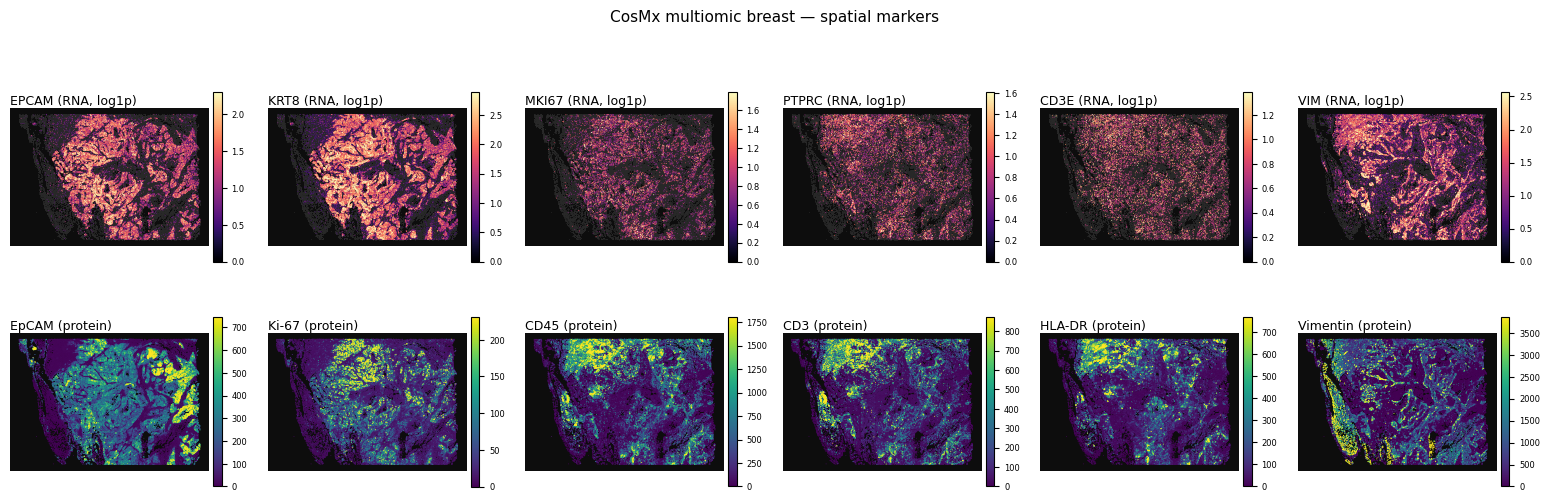

In [32]:
import numpy as np, anndata as ad
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

ROOT = Path('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast')
if 'adata' not in globals():
    adata = ad.read_h5ad(ROOT/'cosmx_multiomic_breast.h5ad')
xy = adata.obsm['spatial']
protein_names = list(adata.uns['protein_var']['protein'])
print('cells:', adata.n_obs, '· genes:', adata.n_vars, '· proteins:', len(protein_names))

def gene_vec(name):
    j = adata.var_names.get_loc(name)
    v = adata.layers['counts'][:, j]
    v = np.asarray(v.todense()).ravel() if hasattr(v,'todense') else np.asarray(v).ravel()
    return np.log1p(v)

def protein_vec(name):
    j = protein_names.index(name)
    return np.asarray(adata.obsm['protein'][:, j]).astype(float)

def spatial_panel(ax, values, title, cmap='magma', s=0.4, qmax=0.99, log_for_zeros=True):
    v = np.asarray(values, dtype=float)
    nz = v[v > 0]
    vmax = float(np.quantile(nz, qmax)) if nz.size else 1.0
    vmin = 0.0
    if log_for_zeros:
        nz_mask = v > 0
        ax.scatter(xy[~nz_mask,0], xy[~nz_mask,1], s=s*0.6, c='#2a2a2a',
                   linewidths=0, rasterized=True)
        order = np.argsort(v[nz_mask])
        ax.scatter(xy[nz_mask,0][order], xy[nz_mask,1][order], s=s,
                   c=v[nz_mask][order], cmap=cmap, vmin=vmin, vmax=vmax,
                   linewidths=0, rasterized=True)
    else:
        order = np.argsort(v)
        ax.scatter(xy[order,0], xy[order,1], s=s, c=v[order],
                   cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0, rasterized=True)
    ax.set_aspect('equal'); ax.set_facecolor('#0d0d0d')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9, loc='left', pad=2)
    return mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin, vmax))

# Markers — adjust freely
GENES    = ['EPCAM', 'KRT8', 'MKI67', 'PTPRC', 'CD3E', 'VIM']
PROTEINS = ['EpCAM', 'Ki-67', 'CD45', 'CD3', 'HLA-DR', 'Vimentin']
GENES    = [g for g in GENES    if g in adata.var_names]
PROTEINS = [p for p in PROTEINS if p in protein_names]
print('plotting genes:',    GENES)
print('plotting proteins:', PROTEINS)

ncol = max(len(GENES), len(PROTEINS))
fig, axes = plt.subplots(2, ncol, figsize=(2.6*ncol, 5.4), facecolor='white')
if ncol == 1:
    axes = np.array(axes).reshape(2,1)

for i, g in enumerate(GENES):
    sm = spatial_panel(axes[0, i], gene_vec(g), f'{g} (RNA, log1p)')
    plt.colorbar(sm, ax=axes[0, i], fraction=0.04, pad=0.02).ax.tick_params(labelsize=6)
for j in range(len(GENES), ncol):
    axes[0, j].axis('off')

for i, p in enumerate(PROTEINS):
    sm = spatial_panel(axes[1, i], protein_vec(p), f'{p} (protein)',
                       cmap='viridis', log_for_zeros=False)
    plt.colorbar(sm, ax=axes[1, i], fraction=0.04, pad=0.02).ax.tick_params(labelsize=6)
for j in range(len(PROTEINS), ncol):
    axes[1, j].axis('off')

fig.suptitle('CosMx multiomic breast — spatial markers', fontsize=11, y=0.99)
fig.tight_layout()
fig.savefig(ROOT/'spatial_markers.png', dpi=200, bbox_inches='tight')
plt.show()

In [42]:
adata

AnnData object with n_obs × n_vars = 152451 × 18942
    obs: 'fov', 'cell_ID', 'nCount_neg', 'nCount_sys', 'cell', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Area', 'Area.um2', 'AspectRatio', 'Width', 'Height', 'Circularity', 'Eccentricity', 'Solidity', 'Perimeter', 'Mean.DAPI', 'Max.DAPI', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'slide_ID', 'tissue', 'Panel', 'assay_type', 'Run_Tissue_name', 'Run_name', 'x', 'y', 'sample', 'leiden_protein', 'leiden_rna'
    var: 'feature_type', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'fov_positions', 'protein_channel_var', 'protein_isotype_var', 'protein_var', 'hvg', 'log1p', 'pca', 'neighbors', 'leiden_rna', 'umap'
    obsm: 'protein', 'protein_channel', 'protein_isotype', 'spatial', 'X_pca', 'X_umap', 'X_umap_rna'
    va

In [43]:
# ---------- Save updated h5ad ----------
adata.write_h5ad(H5AD, compression='gzip')
print('saved', H5AD, '·', round(H5AD.stat().st_size/1e6, 1), 'MB')
print(adata)

saved /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast/cosmx_multiomic_breast.h5ad · 1006.2 MB
AnnData object with n_obs × n_vars = 152451 × 18942
    obs: 'fov', 'cell_ID', 'nCount_neg', 'nCount_sys', 'cell', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Area', 'Area.um2', 'AspectRatio', 'Width', 'Height', 'Circularity', 'Eccentricity', 'Solidity', 'Perimeter', 'Mean.DAPI', 'Max.DAPI', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'slide_ID', 'tissue', 'Panel', 'assay_type', 'Run_Tissue_name', 'Run_name', 'x', 'y', 'sample', 'leiden_protein', 'leiden_rna'
    var: 'feature_type', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'fov_positions', 'protein_channel_var', 'protein_isotype_var', 'protein_var', '

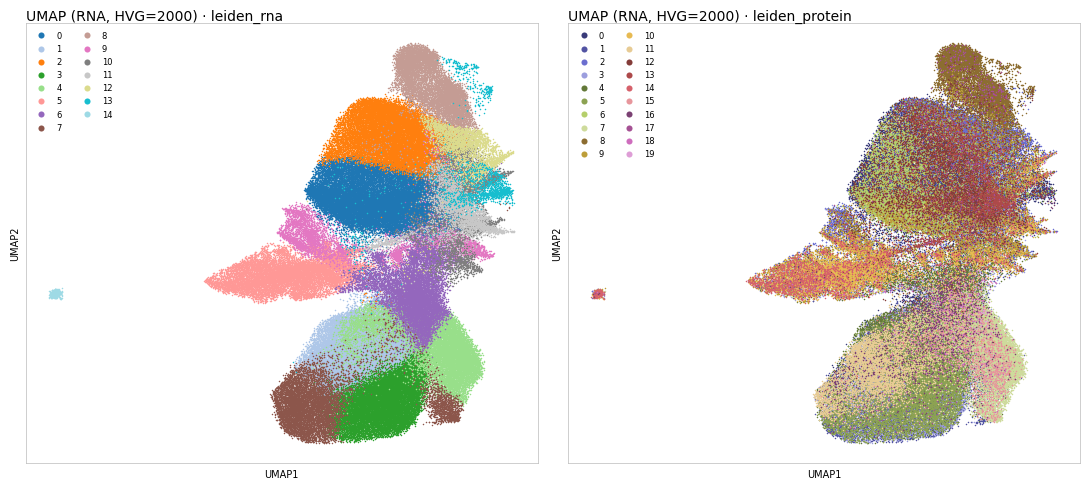

In [46]:
# UMAP (RNA, HVG-PCA-based) coloured by leiden_rna and leiden_protein
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

um = adata.obsm['X_umap_rna']

def umap_panel(ax, labels, title, palette='tab20', s=1.2):
    cats = list(labels.cat.categories) if hasattr(labels,'cat') else list(pd.Categorical(labels).categories)
    cmap = mpl.colormaps[palette].resampled(max(len(cats),3))
    colors = {c: cmap(i) for i,c in enumerate(cats)}
    arr = np.asarray(labels)
    for c in cats:
        m = arr == c
        ax.scatter(um[m,0], um[m,1], s=s, c=[colors[c]], label=str(c),
                   linewidths=0, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_linewidth(0.4); sp.set_color('#aaaaaa')
    ax.set_title(title, fontsize=10, loc='left', pad=2)
    ax.set_xlabel('UMAP1', fontsize=7); ax.set_ylabel('UMAP2', fontsize=7)
    ax.legend(markerscale=4, fontsize=6, ncol=2, loc='best',
              frameon=False).set_zorder(10)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), facecolor='white')
umap_panel(axes[0], adata.obs['leiden_rna'],     'UMAP (RNA, HVG=2000) · leiden_rna')
umap_panel(axes[1], adata.obs['leiden_protein'], 'UMAP (RNA, HVG=2000) · leiden_protein', palette='tab20b')
fig.tight_layout()
fig.savefig(ROOT/'umap_rna_clusters.png', dpi=200, bbox_inches='tight')
plt.show()

In [47]:
import scanpy as sc

In [39]:
# ---------- Protein clustering (work on a temporary AnnData) ----------
protein_names = list(adata.uns['protein_var']['protein'])
P = np.asarray(adata.obsm['protein'], dtype=np.float32)
# arcsinh stabilises immunofluorescence intensities (cofactor 5 is conventional)
ad_p = ad.AnnData(X=np.arcsinh(P / 5.0))
ad_p.var_names = protein_names
ad_p.obs_names = adata.obs_names

sc.pp.scale(ad_p, max_value=10)
sc.tl.pca(ad_p, n_comps=min(30, ad_p.n_vars-1), random_state=0)
sc.pp.neighbors(ad_p, n_neighbors=15, random_state=0)
sc.tl.leiden(ad_p, resolution=0.6, key_added='leiden_protein', random_state=0)

adata.obs['leiden_protein'] = ad_p.obs['leiden_protein'].values
print('leiden_protein clusters:', adata.obs['leiden_protein'].nunique())

leiden_protein clusters: 20


In [45]:
import scanpy as sc
import anndata as ad
import numpy as np
from pathlib import Path

ROOT = Path('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/cosmx_multiomic_breast')
H5AD = ROOT/'cosmx_multiomic_breast.h5ad'

if 'adata' not in globals():
    adata = ad.read_h5ad(H5AD)

print('start:', adata.shape)

# ---------- RNA clustering ----------
# HVG on raw counts (Seurat-v3) before normalisation. mask only — does NOT subset adata.
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3', layer='counts')
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=30, mask_var='highly_variable', random_state=0)
sc.pp.neighbors(adata, n_neighbors=15, random_state=0)
sc.tl.umap(adata, random_state=0)               # uses neighbors graph built from HVG-PCA
sc.tl.leiden(adata, resolution=0.7, key_added='leiden_rna', random_state=0)

# Stash UMAP under a clear key so a later protein UMAP doesn't overwrite it
adata.obsm['X_umap_rna'] = adata.obsm['X_umap'].copy()
print('leiden_rna clusters:', adata.obs['leiden_rna'].nunique())
print('UMAP key: obsm[\"X_umap_rna\"]', adata.obsm['X_umap_rna'].shape)

start: (152451, 18942)
leiden_rna clusters: 15
UMAP key: obsm["X_umap_rna"] (152451, 2)


---
## Modality-specific clustering
Cluster cells separately on RNA and protein, then write the labels back as `obs.leiden_rna` and `obs.leiden_protein`.

---
## Spatial expression visualisation
Plot a few genes and proteins on the slide to sanity-check the assembled object.

In [41]:
adata

AnnData object with n_obs × n_vars = 152451 × 18942
    obs: 'fov', 'cell_ID', 'nCount_neg', 'nCount_sys', 'cell', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Area', 'Area.um2', 'AspectRatio', 'Width', 'Height', 'Circularity', 'Eccentricity', 'Solidity', 'Perimeter', 'Mean.DAPI', 'Max.DAPI', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'slide_ID', 'tissue', 'Panel', 'assay_type', 'Run_Tissue_name', 'Run_name', 'x', 'y', 'sample', 'leiden_protein', 'leiden_rna'
    var: 'feature_type', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'fov_positions', 'protein_channel_var', 'protein_isotype_var', 'protein_var', 'hvg', 'log1p', 'pca', 'neighbors', 'leiden_rna', 'umap'
    obsm: 'protein', 'protein_channel', 'protein_isotype', 'spatial', 'X_pca', 'X_umap', 'X_umap_rna'
    va